In [1]:
from pathlib import Path
import scipy.interpolate as spi
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.profiles import PowerSeriesProfile
from desc.profiles import SplineProfile
from desc.plotting import plot_1d, plot_section, plot_surfaces
from desc.grid import LinearGrid
from desc.grid import Grid
from desc.grid import QuadratureGrid
import desc.compute._profiles
import matplotlib.pyplot as plt
from desc.optimize import Optimizer
from scipy.io import savemat
from scipy.io import loadmat
from desc.compute import compute as compute_fun
from desc.objectives import (
    get_fixed_boundary_constraints,
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    ForceBalance,
)
import time
from joblib import Parallel, delayed

DESC version 0.12.3,using JAX backend, jax version=0.4.33, jaxlib version=0.4.33, dtype=float64
Using device: CPU, with 45.98 GB available memory


### output2D脚本用于输出二维平衡。
##### 建议采用control+shift组合键运行**需要的代码块**。
### 第一步，设置路径。
##### 在1.1代码块的前2行指定计算好的平衡hdf5文件，以及最终的目标输出文件夹。然后运行1.1代码块。

In [4]:
################## 1.1代码块 ##################
################## 1.1代码块 ##################

inputPath = r'D:\CPC\R835\0.05-0.90(256_64_16)\KBM\Beta1.8%\R835_18.hdf5'
outputPath =  r'D:\CPC\R835\0.05-0.90(256_64_16)\KBM\Beta1.8%\TEST3'

folder_path = Path(outputPath)
folder_path.mkdir(exist_ok=True)
folder_path = Path(outputPath+r'\more')
folder_path.mkdir(exist_ok=True)

### 第二步，定义函数。
##### 运行2.1代码块，代码块较长，运行后请滑动界面至下方第三步。

In [3]:
################## 2.1代码块 ##################
################## 2.1代码块 ##################

def get_psip_profile(iota_params, iota_modes):
    
    psi_max = np.array(eq.compute('psi',Grid(np.array([1.0,0.0,0.0])))['psi'])[0]
    
    psip_params = iota_params.copy()
    psip_modes = iota_modes.copy()
    
    for i in range(0,len(iota_modes)):
        psip_modes[i] = iota_modes[i] + 2
        psip_params[i] = iota_params[i]*2/(iota_modes[i]+2)*psi_max
        
    psip_modes = [0] + psip_modes
    psip_params = [0] + psip_params 
    
    return PowerSeriesProfile(params=psip_params, modes=psip_modes)




def get_rho_bspline(psip_profile, rho_num):
    
    rho_grid = np.linspace(0,1,rho_num)
    rho_index = np.zeros((rho_num,3))
    rho_index[:,0] = rho_grid
    psip_grid = psip_profile.compute(Grid(rho_index))
    rho_ipo =  spi.splrep(psip_grid,rho_grid,k=5)
    
    return rho_ipo


def get_rho(psip_num,ratio1,ratio2):

    spsip_min = ratio1*psip_max
    spsip_max = ratio2*psip_max
    psip_grid = np.linspace(spsip_min, spsip_max, psip_num)
    rho_grid = spi.splev(psip_grid,rho_ipo)
    print("min r/a:")
    print(rho_grid[0])
    print("max r/a:")
    print(rho_grid[-1])


def get_rho_theta_phi(staggered,psip_num,ratio1,ratio2,theta_B_num,sample_num):
    
    spsip_min = ratio1*psip_max
    spsip_max = ratio2*psip_max
    psip_grid = np.linspace(spsip_min, spsip_max, psip_num)
    rho_grid = spi.splev(psip_grid,rho_ipo)
    print("min r/a:")
    print(rho_grid[0])
    print("max r/a:")
    print(rho_grid[-1])
    print("")
    
    #设定我们想要的theta_B网格
    theta_V_grid = np.zeros((psip_num, theta_B_num))
    
    if(staggered==0):
        dtheta_B = 2*np.pi/theta_B_num
        theta_B_min = -np.pi + dtheta_B/2
        theta_B_max =  np.pi - dtheta_B/2
        theta_B_grid = np.linspace(theta_B_min, theta_B_max,theta_B_num)
    if(staggered==1):
        dtheta_B = 2*np.pi/theta_B_num
        theta_B_min = -np.pi
        theta_B_max =  np.pi - dtheta_B
        theta_B_grid = np.linspace(theta_B_min, theta_B_max,theta_B_num)

    #设置theta_V的采样点，计算相应的theta_B，为theta_B到theta_V的插值做准备
    theta_V_sample_num = sample_num

    if(staggered==0):
        theta_V_sample_min = -np.pi
        theta_V_sample_max =  np.pi
    if(staggered==1):
        theta_V_sample_min = -np.pi - dtheta_B/2
        theta_V_sample_max =  np.pi - dtheta_B/2
        
    theta_V_sample = np.linspace(theta_V_sample_min,theta_V_sample_max,theta_V_sample_num)
    theta_V_sample = theta_V_sample[0:theta_V_sample_num-1]
    theta_V_index = np.zeros((theta_V_sample_num-1,3))

    theta_V_index[:,1] = theta_V_sample

    meshr = np.array([0.0])
    meshz = np.array([0.0])
    mesht = theta_V_sample

    for psip_index in range(0, psip_num):
    
        print(psip_index)

        meshr[0] = rho_grid[psip_index]

        rtz = [meshr,mesht,meshz]
        
        meshgrid = Grid.create_meshgrid(rtz)
        
        theta_B_sample = np.array(eq.compute("theta_B", meshgrid)['theta_B'])

        # plt.figure()

        # plt.plot(theta_B_sample)
        # plt.plot(theta_V_sample)

        #对theta_B到theta_V进行样条插值
        ipo = spi.splrep(theta_B_sample,theta_V_sample,k=5)

        #得到theta_Boozer对应的theta_V
        theta_V_1d = spi.splev(theta_B_grid,ipo)
        theta_V_grid[psip_index] = theta_V_1d
    
    return psip_grid, theta_B_grid, rho_grid, theta_V_grid




def print_equlibrium(psip_grid, theta_B_grid, rho_grid, theta_V_grid):
    
    psip_num = theta_V_grid.shape[0]
    theta_B_num = theta_V_grid.shape[1]
    psi_max = np.array(eq.compute('psi',Grid(np.array([1.0,0.0,0.0])))['psi'])[0]
    
    matrix_list = \
    ['R','R_r','R_t','R_rr','R_rt','R_tt',\
     'Z','Z_r','Z_t','Z_rr','Z_rt','Z_tt',\
     'sqrt(g)','sqrt(g)_r','sqrt(g)_t','sqrt(g)_rr','sqrt(g)_rt','sqrt(g)_tt',\
     '|B|','|B|_r','|B|_t','|B|_rr','|B|_rt','|B|_tt',\
     'lambda','lambda_r','lambda_t','lambda_rr','lambda_rt','lambda_tt',\
     'g_rr','g_tt','g_zz','g_rt','g_rz','g_tz','g_tt_r','g_tz_r',\
     'g^rr','g^tt','g^zz','g^rt','g^rz','g^tz',\
     'g^rr_r','g^rt_r','g^rz_r','g^tt_r','g^tz_r','g^zz_r',\
     'g^rr_t','g^rt_t','g^rz_t','g^tt_t','g^tz_t','g^zz_t',\
     'G','G_r','G_rr','I','I_r','I_rr','iota','iota_r','iota_rr','p','p_r',\
     'kappa_n','kappa_g','J_parallel','rho','q','psi','psi_r']
    
    matrix_num=len(matrix_list)
    output=np.zeros((matrix_num,psip_num,theta_B_num))
    
    Grid_index = np.zeros((psip_num * theta_B_num, 3))
    for i in range(0, psip_num):
        for j in range(0, theta_B_num):
            Grid_index[i*theta_B_num + j][0] = rho_grid[i]
            Grid_index[i*theta_B_num + j][1] = theta_V_grid[i][j]
    
    for index in range(0, matrix_num):
        field = np.array(eq.compute(matrix_list[index], Grid(Grid_index))[matrix_list[index]])
        for i in range(0, psip_num):
            for j in range(0, theta_B_num):
                output[index][i][j] = field[i * theta_B_num + j]
    
    #手算部分导数
    dq_dr = -pow(output[71],2)*output[63]
    dq_dr2 = -2*output[71]*dq_dr*output[63]-pow(output[71],2)*output[64]
    
    psi_p = np.zeros((psip_num,theta_B_num))
    for i in range(0,psip_num):
        psi_p[i,:] = psip_grid[i]
    dpsi_p_dr = 2*psi_max*output[62]*output[70]
    dpsi_p_dr2 = 2*psi_max*(output[62]+output[63]*output[70])
    
    theta_b = np.zeros((psip_num,theta_B_num))
    for j in range(0,theta_B_num):
        theta_b[:,j] = theta_B_grid[j]
        
    dpsi_t_dr2 = np.zeros((psip_num,theta_B_num))
    dpsi_t_dr2[:,:] = 2*psi_max
    
    index_min = np.array([0.0,0.0,0.0])
    Rc = np.array(eq.compute('R', Grid(index_min))['R'])[0]
    Bc = np.array(eq.compute('|B|', Grid(index_min))['|B|'])[0]

    path =  outputPath+r'\normal_equilibrium.mat'
                
    savemat(path,\
            {'R':output[0], 'dR_dr':output[1], 'dR_dt':output[2],'dR_dr2':output[3], 'dR_drdt':output[4], 'dR_dt2':output[5],\
             'Z':output[6], 'dZ_dr':output[7], 'dZ_dt':output[8],'dZ_dr2':output[9], 'dZ_drdt':output[10], 'dZ_dt2':output[11],\
             'J':output[12], 'dJ_dr':output[13], 'dJ_dt':output[14],'dJ_dr2':output[15], 'dJ_drdt':output[16], 'dJ_dt2':output[17],\
             'B':output[18], 'dB_dr':output[19], 'dB_dt':output[20],'dB_dr2':output[21], 'dB_drdt':output[22], 'dB_dt2':output[23],\
             'lambda':output[24], 'dlambda_dr':output[25], 'dlambda_dt':output[26],\
             'dlambda_dr2':output[27], 'dlambda_drdt':output[28], 'dlambda_dt2':output[29],\
             'gcov_rr':output[30], 'gcov_tt':output[31], 'gcov_zz':output[32], 'gcov_rt':output[33],\
             'gcov_rz':output[34], 'gcov_tz':output[35], 'dgcov_tt_dr':output[36], 'dgcov_tz_dr':output[37],\
             'gcon_rr':output[38], 'gcon_tt':output[39], 'gcon_zz':output[40],\
             'gcon_rt':output[41], 'gcon_rz':output[42], 'gcon_tz':output[43],\
             'dgcon_rr_dr':output[44], 'dgcon_rt_dr':output[45], 'dgcon_rz_dr':output[46],\
             'dgcon_tt_dr':output[47], 'dgcon_tz_dr':output[48], 'dgcon_zz_dr':output[49],\
             'dgcon_rr_dt':output[50], 'dgcon_rt_dt':output[51], 'dgcon_rz_dt':output[52],\
             'dgcon_tt_dt':output[53], 'dgcon_tz_dt':output[54], 'dgcon_zz_dt':output[55],\
             'g_curr':output[56], 'dg_curr_dr':output[57], 'dg_curr_dr2':output[58],\
             'i_curr':output[59], 'di_curr_dr':output[60], 'di_curr_dr2':output[61],\
             'iota':output[62], 'diota_dr':output[63], 'diota_dr2':output[64],\
             'pres':output[65], 'dpres_dr':output[66],\
             'kappa_n':output[67], 'kappa_g':output[68],'jp':output[69],'rho':output[70],\
             'q':output[71], 'dq_dr':dq_dr, 'dq_dr2':dq_dr2,\
             'psi_t':output[72], 'dpsi_t_dr':output[73], 'dpsi_t_dr2':dpsi_t_dr2,\
             'psi_p':psi_p, 'dpsi_p_dr':dpsi_p_dr, 'dpsi_p_dr2':dpsi_p_dr2,\
             'theta_v':theta_V_grid, 'theta_b':theta_b, 'N_rho':psip_num, 'N_theta':theta_B_num, 'Rc':Rc, 'Bc':Bc, 'psi_pm':psip_max})




def print_more_1d(num1,num2):
    
    more_list = ['R', 'Z', 'sqrt(g)', 'sqrt(g)_B', 'lambda', 'g^rr', 'g^tt', 'g^zz', 'g^rt', 'g^rz', 'g^tz', \
                 'kappa_n', 'kappa_g', 'J_parallel', 'nu', 'nu_t', 'g_rr', 'g_tt', 'g_zz', 'g_rt', 'g_rz', 'g_tz', '|B|']
    
    more_rho_num = num1
    more_rho_grid = np.linspace(0.001,1.0,more_rho_num)
    more_rho_index = np.zeros((more_rho_num, 3))
    more_rho_index[:,0] = more_rho_grid
    more_p = np.array(eq.compute('p',Grid(more_rho_index))['p'])
    more_dp_dr = np.array(eq.compute('p_r',Grid(more_rho_index))['p_r'])
    more_g_curr = np.array(eq.compute('G',Grid(more_rho_index))['G'])
    more_i_curr = np.array(eq.compute('I',Grid(more_rho_index))['I'])
    more_q = np.array(eq.compute('q',Grid(more_rho_index))['q'])
    more_psi_t = np.array(eq.compute('psi',Grid(more_rho_index))['psi'])
    more_iota = np.array(eq.compute('iota',Grid(more_rho_index))['iota'])
    more_iota_r = np.array(eq.compute('iota_r',Grid(more_rho_index))['iota_r'])
    more_chi_r = np.array(eq.compute('chi_r',Grid(more_rho_index))['chi_r'])
    more_psi_p = np.array(psip_profile.compute(Grid(more_rho_index)))
    
    more_thetav_num = num2
    more_thetav_grid = np.linspace(-np.pi,np.pi,more_thetav_num + 1)
    more_thetav_grid = more_thetav_grid[0:more_thetav_num]

    path =  outputPath+r'\more_1d.mat'
        
    savemat(path,\
        {'more_pres':more_p, 'more_dpres_dr':more_dp_dr,\
         'more_g_curr':more_g_curr, 'more_i_curr':more_i_curr,\
         'more_q':more_q, 'more_psi_t':more_psi_t,\
         'more_iota':more_iota, 'more_diota_dr':more_iota_r,\
         'more_dpsi_p_dr':more_chi_r, 'more_psi_p':more_psi_p,\
         'more_rho':more_rho_grid,'more_theta_v':more_thetav_grid})






def print_more_3d(rho_index):
    
    more_list = ['R', 'Z', 'sqrt(g)', 'sqrt(g)_B', 'lambda', 'g^rr', 'g^tt', 'g^zz', 'g^rt', 'g^rz', 'g^tz', \
                 'kappa_n', 'kappa_g', 'J_parallel', 'nu', 'nu_t', 'g_rr', 'g_tt', 'g_zz', 'g_rt', 'g_rz', 'g_tz', '|B|']
    
    more_rho_grid = np.linspace(0.001,1.0,more_rho_num)
    more_thetav_grid = np.linspace(-np.pi,np.pi,more_thetav_num + 1)
    more_thetav_grid = more_thetav_grid[0:more_thetav_num]
    
    more_thetav_index = np.zeros((more_thetav_num, 3))
    
    output_R = np.zeros((1, more_thetav_num))
    output_Z = np.zeros((1, more_thetav_num))
    output_J = np.zeros((1, more_thetav_num))
    output_lambda = np.zeros((1, more_thetav_num))
    output_gcon_rr = np.zeros((1, more_thetav_num))
    output_gcon_tt = np.zeros((1, more_thetav_num))
    output_gcon_zz = np.zeros((1, more_thetav_num))
    output_gcon_rt = np.zeros((1, more_thetav_num))
    output_gcon_rz = np.zeros((1, more_thetav_num))
    output_gcon_tz = np.zeros((1, more_thetav_num))
    output_kappa_n = np.zeros((1, more_thetav_num))
    output_kappa_g = np.zeros((1, more_thetav_num))
    output_jp = np.zeros((1, more_thetav_num))
    output_nu = np.zeros((1, more_thetav_num))
    output_nu_t = np.zeros((1, more_thetav_num))
    output_J_B = np.zeros((1, more_thetav_num))
    output_g_rr = np.zeros((1, more_thetav_num))
    output_g_tt = np.zeros((1, more_thetav_num))
    output_g_zz = np.zeros((1, more_thetav_num))
    output_g_rt = np.zeros((1, more_thetav_num))
    output_g_rz = np.zeros((1, more_thetav_num))
    output_g_tz = np.zeros((1, more_thetav_num))
    output_B = np.zeros((1, more_thetav_num))
    
    more_thetav_index[:,1] = more_thetav_grid
    more_thetav_index[:,0] = more_rho_grid[rho_index]

    meshr = np.array([0.0])
    meshz = np.array([0.0])
    mesht = more_thetav_grid
    meshr[0] = more_rho_grid[rho_index]
    rtz = [meshr,mesht,meshz]
    meshgrid = Grid.create_meshgrid(rtz)
        
    more_result = eq.compute(more_list,meshgrid)
        
    output_R = np.array(more_result['R'])
    output_Z = np.array(more_result['Z'])
    output_J = np.array(more_result['sqrt(g)'])
    output_lambda = np.array(more_result['lambda'])
    output_gcon_rr = np.array(more_result['g^rr'])
    output_gcon_tt = np.array(more_result['g^tt'])
    output_gcon_zz = np.array(more_result['g^zz'])
    output_gcon_rt = np.array(more_result['g^rt'])
    output_gcon_rz = np.array(more_result['g^rz'])
    output_gcon_tz = np.array(more_result['g^tz'])
    output_kappa_n = np.array(more_result['kappa_n'])
    output_kappa_g = np.array(more_result['kappa_g'])
    output_jp = np.array(more_result['J_parallel'])
    
    output_nu = np.array(more_result['nu'])
    output_nu_t = np.array(more_result['nu_t'])
    output_J_B = np.array(more_result['sqrt(g)'])/np.array(more_result['sqrt(g)_B'])
    output_g_rr = np.array(more_result['g_rr'])
    output_g_tt = np.array(more_result['g_tt'])
    output_g_zz = np.array(more_result['g_zz'])
    output_g_rt = np.array(more_result['g_rt'])
    output_g_rz = np.array(more_result['g_rz'])
    output_g_tz = np.array(more_result['g_tz'])
    output_B = np.array(more_result['|B|'])
    
    suffix = '_'+str(rho_index+1)

    path = outputPath+r'\more\more_3d_'+str(rho_index+1)+'.mat'
    
    savemat(path,\
        {'more_R'+suffix:output_R,'more_Z'+suffix:output_Z,'more_J'+suffix:output_J,'more_lambda'+suffix:output_lambda,\
         'more_gcon_rr'+suffix:output_gcon_rr, 'more_gcon_tt'+suffix:output_gcon_tt, 'more_gcon_zz'+suffix:output_gcon_zz,\
         'more_gcon_rt'+suffix:output_gcon_rt, 'more_gcon_rz'+suffix:output_gcon_rz, 'more_gcon_tz'+suffix:output_gcon_tz,\
         'more_kappa_n'+suffix:output_kappa_n, 'more_kappa_g'+suffix:output_kappa_g, 'more_jp'+suffix:output_jp,\
         'more_nu'+suffix:output_nu,'more_dnu_dt'+suffix:output_nu_t,\
         'more_J_B'+suffix:output_J_B,\
         'more_gcov_rr'+suffix:output_g_rr,'more_gcov_tt'+suffix:output_g_tt,'more_gcov_zz'+suffix:output_g_zz,\
         'more_gcov_rt'+suffix:output_g_rt,'more_gcov_rz'+suffix:output_g_rz,'more_gcov_tz'+suffix:output_g_tz,\
         'more_B'+suffix:output_B})





def print_plot_data(psip_grid, theta_B_grid, rho_grid, theta_V_grid):
    
    psip_num = theta_V_grid.shape[0]
    theta_B_num = theta_V_grid.shape[1]
    psi_max = np.array(eq.compute('psi',Grid(np.array([1.0,0.0,0.0])))['psi'])[0]
    
    sp_list = ['R', 'Z']
    
    sp_rho_index = np.zeros((psip_num, 3))
    sp_thetav_index = np.zeros((theta_B_num, 3))
    sp_rho_index[:,0] = rho_grid 

    index_min = np.array([0.0,0.0,0.0])
    
    sp_q = np.array(eq.compute('q',Grid(sp_rho_index))['q'])
    
    output_R = np.zeros((psip_num, theta_B_num))
    output_Z = np.zeros((psip_num, theta_B_num))
    
    #nu和nu_t的加密必须每个磁面单独计算

    for i in range(0, psip_num):
        
        print(i)
        sp_thetav_index[:,1] = theta_V_grid[i]
        sp_thetav_index[:,0] = rho_grid[i]
        
        sp_result = eq.compute(sp_list,Grid(sp_thetav_index))
        
        output_R[i] = np.array(sp_result['R'])
        output_Z[i] = np.array(sp_result['Z'])

    path =  outputPath+r'\plot.mat'
    
    savemat(path,\
            {'qplot':sp_q,'psiplot':psip_grid,
             'Rplot':output_R,'Zplot':output_Z,
             'rhoplot':rho_grid})

### 第三步，检查平衡。
##### 运行3.1代码块，可以检查输出的q和p剖面，磁面形状以及平衡误差。

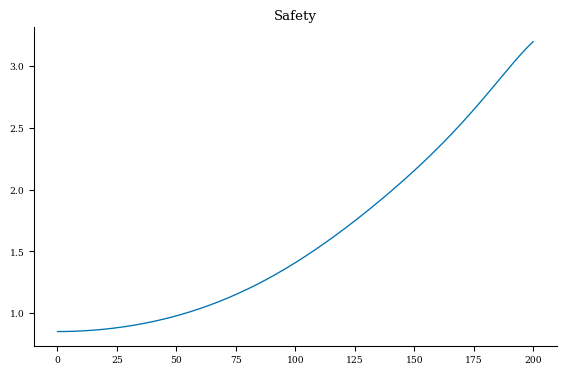

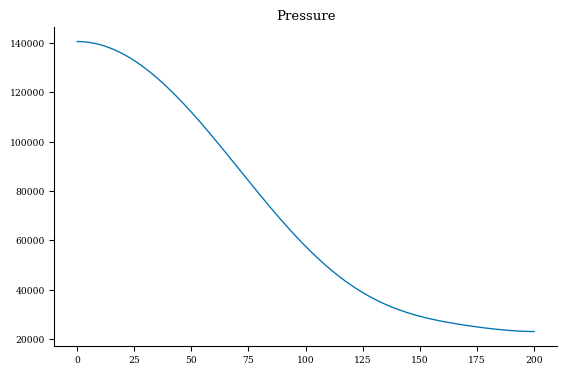

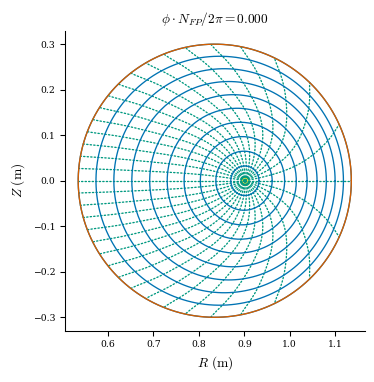

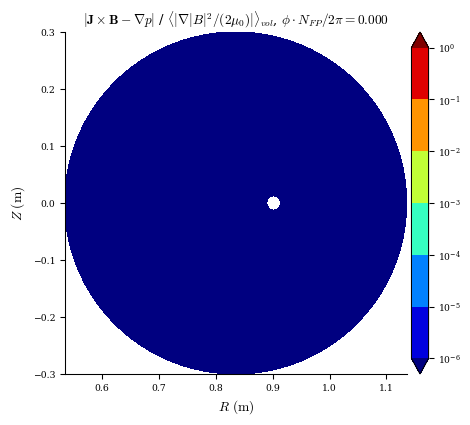

In [4]:
################## 3.1代码块 ##################
################## 3.1代码块 ##################

eq = desc.io.load(inputPath)
iota = eq.iota.copy()
iota_modes = iota.basis.modes[:,0]
iota_params = iota.params
psip_profile = get_psip_profile(iota_params, iota_modes)
rho_ipo = get_rho_bspline(psip_profile, 1024)
psip_max = np.array(psip_profile.compute(Grid(np.array([1.0,0.0,0.0]))))[0]

plt.figure()
plt.plot(eq.compute('q',LinearGrid(L=200))['q'])
plt.title('Safety')
plt.figure()
plt.plot(eq.compute('p',LinearGrid(L=200))['p'])
plt.title('Pressure')

plot_surfaces(eq,10,36)
plot_section(eq, "|F|", norm_F=True, log=True);

### 第四步，输出平衡。
##### 1.在4.1代码块的前4行，依次指定模拟区域的归一化极向磁通的最小值，最大值，径向网格数，沿场线方向网格数。
##### 运行4.1代码块，下方会输出对应r/a的最小值，最大值。可反复调整并运行4.1代码块直到范围满足需要。
##### 2.运行4.2代码块，计算用于模拟的磁面坐标，窗口会不断输出当前磁面索引，索引输出至gridPsip-1则运行结束。
##### 3.运行4.3代码块，请等待运行结束，目标文件夹内将出现normal_equilibrium.mat。
##### 4.运行4.4代码块，请等待运行结束，目标文件夹内将出现more_1d.mat。
##### 5.运行4.5代码块，请等待运行结束，目标文件夹内的more文件夹内将出现more_3d_i.mat，1<=i<=1024。
##### 6.运行4.6代码块，计算用于画图的磁面坐标，窗口会不断输出当前磁面索引，索引输出至1023则运行结束。
##### 7.运行4.7代码块，请等待运行结束，目标文件夹内将出现plot.mat。

##### **除非电脑配置足够好，请不要将这些代码块整合，否则可能遭遇运行时程序崩溃。**
##### **四类程序崩溃及其处理方法：**
##### &#9312; 在1.2.3.其中任何一步崩溃，请重新运行脚本至此处，运行1.2.3.。
##### &#9313; 在4.崩溃，请重新运行脚本至此处，然后跳过2.3.，运行1.4.。
##### &#9314; 在5.崩溃，请重新运行脚本至此处，然后跳过2.3.，运行1.4.5.。
##### &#9315; 在6.7.其中任何一步崩溃，请重新运行脚本至此处，然后跳过2.3.4.5.，运行1.6.7.。

##### **最终在目标文件夹下你将得到：**
##### **normal_equilibrium.mat**
##### **more_1d.mat**
##### **more文件夹以及文件夹下的more_3d_i.mat，1<=i<=1024**
##### **plot.mat**

In [5]:
################## 4.1代码块 ##################
################## 4.1代码块 ##################

nPsipMin = 0.00513
nPsipMax = 0.889
gridPsip = 256
gridThtea = 64

get_rho(gridPsip,nPsipMin,nPsipMax)

min r/a:
0.04999465983840647
max r/a:
0.900464796781303


In [6]:
################## 4.2代码块 ##################
################## 4.2代码块 ##################

psip_grid, theta_B_grid, rho_grid, theta_V_grid = get_rho_theta_phi(0,gridPsip,nPsipMin,nPsipMax,gridThtea,4097)

min r/a:
0.04999465983840647
max r/a:
0.900464796781303

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255


In [7]:
################## 4.3代码块 ##################
################## 4.3代码块 ##################

print_equlibrium(psip_grid, theta_B_grid, rho_grid, theta_V_grid)

In [8]:
################## 4.4代码块 ##################
################## 4.4代码块 ##################

more_rho_num = 1024
more_thetav_num = 1024
print_more_1d(more_rho_num,more_thetav_num)

In [10]:
################## 4.5代码块 ##################
################## 4.5代码块 ##################

if __name__ == '__main__':
    
    index = np.arange(more_rho_num)
    start_time = time.time()
    Parallel(n_jobs=8, verbose=100)(delayed(print_more_3d)(i) for i in index)
    end_time = time.time()

    print("并行处理时间：", end_time - start_time)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    7.7s
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    7.9s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:    7.9s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:    8.0s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:    8.0s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:    8.0s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:    8.0s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:    8.1s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    8.2s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:    8.4s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:    8.5s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:    8.5s
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:    8.6s
[Parallel(n_jobs=8)]: Done  14 tasks      | elapsed:    8.6s
[Parallel(n_jobs=8)]: Done  15 tasks      | elapsed:    8.6s
[Parallel(

In [11]:
################## 4.6代码块 ##################
################## 4.6代码块 ##################

psip_grid, theta_B_grid, rho_grid, theta_V_grid = get_rho_theta_phi(0,1024,nPsipMin,nPsipMax,1024,4097)

min r/a:
0.04999465983840647
max r/a:
0.900464796781303

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
2

In [12]:
################## 4.7代码块 ##################
################## 4.7代码块 ##################

print_plot_data(psip_grid, theta_B_grid, rho_grid, theta_V_grid)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27